Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Assignment 15: Loan Default Prediction**

In [93]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

## 1. Data Analysis and Cleaning

In [75]:
# Download and load the dataset
dataset = fetch_ucirepo(id=350)
df = dataset.data.features.copy()
# Replace the original X1–X23 names with descriptive names
df.columns = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE","PAY_0", "PAY_2", "PAY_3", "PAY_4",
    "PAY_5", "PAY_6", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5",
    "BILL_AMT6", "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",  "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]
df["default"] = dataset.data.targets.iloc[:, 0]
# Display the shape and head
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [98]:
# summary statistics
#df.info()
display(df.describe().round(2))

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.80,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,129747.66,0.49,0.73,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,1000000.00,2.00,4.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


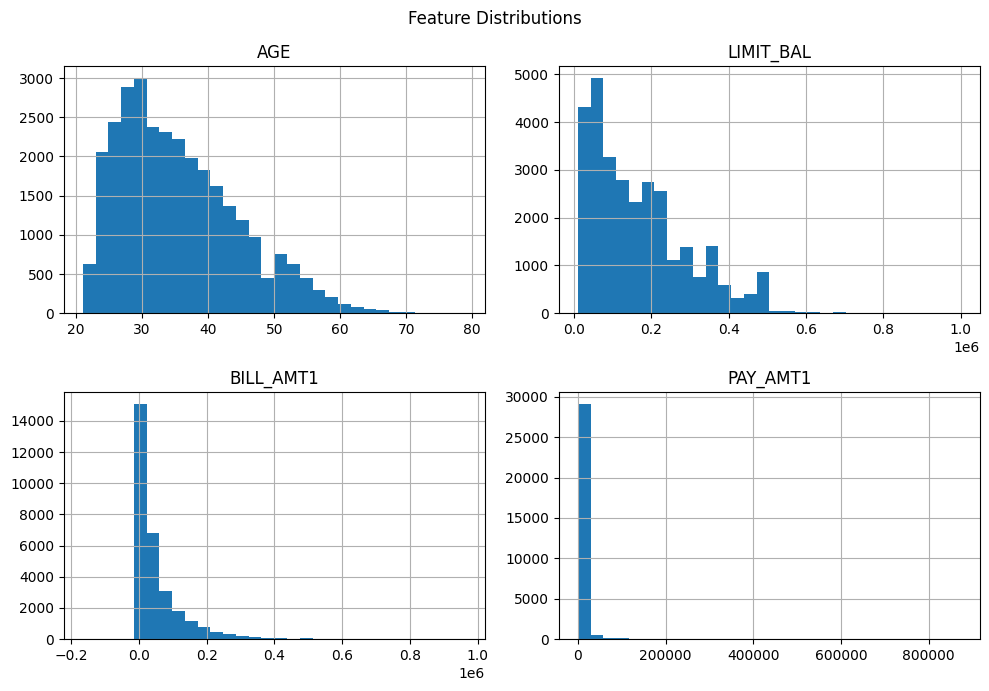

In [77]:
# Visualize distributions
df[["AGE", "LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]].hist(bins=30, figsize=(10, 7))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

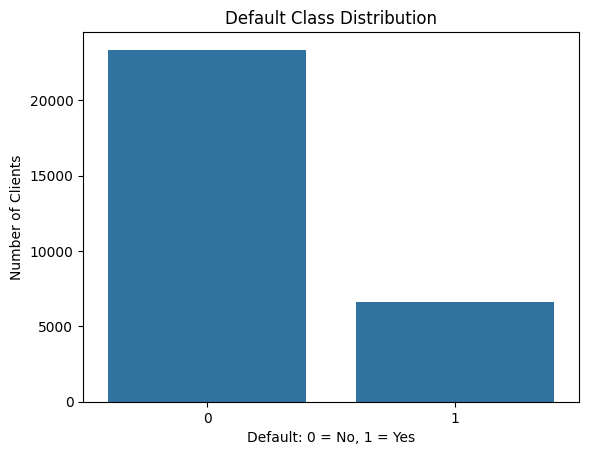

In [78]:
sns.countplot(data=df, x="default")
plt.title("Default Class Distribution")
plt.xlabel("Default: 0 = No, 1 = Yes")
plt.ylabel("Number of Clients")
plt.show()

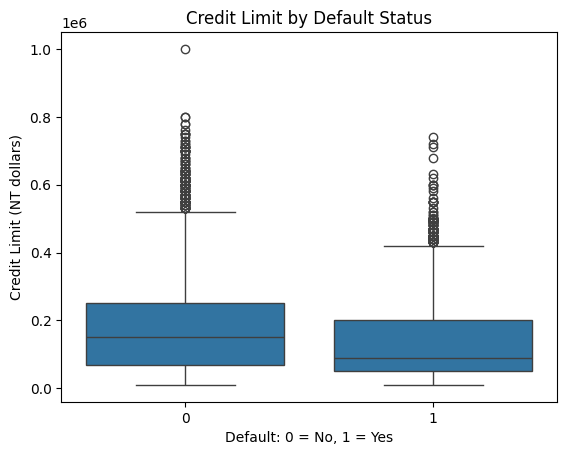

In [79]:
# Visualize relationships
sns.boxplot(data=df, x="default", y="LIMIT_BAL")
plt.title("Credit Limit by Default Status")
plt.xlabel("Default: 0 = No, 1 = Yes")
plt.ylabel("Credit Limit (NT dollars)")
plt.show()

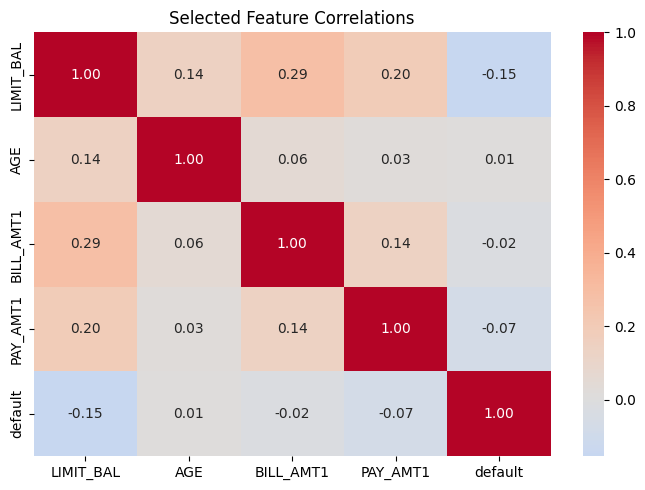

In [80]:
# Correlations among selected numerical features
selected = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1", "default"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[selected].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Selected Feature Correlations")
plt.tight_layout()
plt.show()

In [81]:
# Clean category codes and select features
df["EDUCATION"] = df["EDUCATION"].where(df["EDUCATION"].isin([1, 2, 3, 4]), 0)
df["MARRIAGE"] = df["MARRIAGE"].where(df["MARRIAGE"].isin([1, 2, 3]), 0)
# Remove records only if the target is missing
df = df.dropna(subset=["default"]).copy()
X = df.drop(columns="default")
y = df["default"].astype(int)

In [82]:
# Split before fitting preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [83]:
# Handle missing values
categorical_columns = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
numerical_columns = [column for column in X_train.columns if column not in categorical_columns]
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
numeric_imputer = SimpleImputer(strategy="median")
category_imputer = SimpleImputer(strategy="most_frequent")
X_train_clean[numerical_columns] = numeric_imputer.fit_transform(X_train[numerical_columns])
X_test_clean[numerical_columns] = numeric_imputer.transform(X_test[numerical_columns])
X_train_clean[categorical_columns] = category_imputer.fit_transform(X_train[categorical_columns])
X_test_clean[categorical_columns] = category_imputer.transform(X_test[categorical_columns])

In [84]:
# Encode categorical variables
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train_clean[categorical_columns])
X_test_encoded = encoder.transform(X_test_clean[categorical_columns])

In [85]:
# Normalize numerical features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_clean[numerical_columns])
X_test_scaled = scaler.transform(X_test_clean[numerical_columns])

In [86]:
# Combine the numerical and categorical features for model training
X_train_processed = np.hstack([X_train_scaled, X_train_encoded])
X_test_processed = np.hstack([X_test_scaled, X_test_encoded])
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (24000, 89)
Testing shape: (6000, 89)


## 2. Feature Engineering

In [87]:
# New features
bill_columns = [f"BILL_AMT{i}" for i in range(1, 7)]
payment_columns = [f"PAY_AMT{i}" for i in range(1, 7)]
status_columns = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
X_train = X_train.copy()
X_test = X_test.copy()
for frame in [X_train, X_test]:
    frame["AVG_BILL"] = frame[bill_columns].mean(axis=1)
    frame["AVG_PAYMENT"] = frame[payment_columns].mean(axis=1)
    frame["DELAY_MONTHS"] = (frame[status_columns] > 0).sum(axis=1)
    frame["BILL_LIMIT_RATIO"] = (frame["BILL_AMT1"] / frame["LIMIT_BAL"].where(frame["LIMIT_BAL"] != 0))
X_train[["AVG_BILL", "AVG_PAYMENT", "DELAY_MONTHS", "BILL_LIMIT_RATIO"]].head()

,AVG_BILL,AVG_PAYMENT,DELAY_MONTHS,BILL_LIMIT_RATIO
22788,165490.000000,6583.333333,4,1.011069
29006,8.833333,8.833333,1,0.000000
16950,8576.833333,669.333333,2,1.017100
22280,186262.333333,6947.833333,0,0.940359
11346,30.333333,254.333333,1,0.000000


## 3. Model Building and Evaluation

In [88]:
# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_processed, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [89]:
# Evaluate accuracy and display the classification report
y_pred = model.predict(X_test_processed)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred, labels=[0, 1], target_names=["No Default", "Default"], digits=4, zero_division=0
))

Accuracy: 0.8123

Classification Report:
              precision    recall  f1-score   support

  No Default     0.8372    0.9422    0.8866      4673
     Default     0.6356    0.3549    0.4555      1327

    accuracy                         0.8123      6000
   macro avg     0.7364    0.6486    0.6711      6000
weighted avg     0.7926    0.8123    0.7913      6000



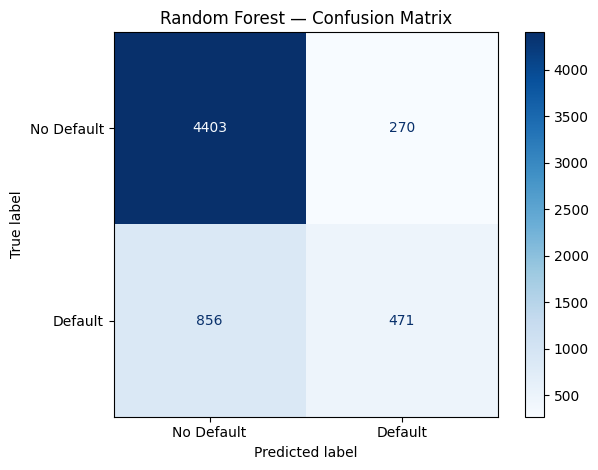

In [90]:
# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
cm_display.plot(cmap="Blues", values_format="d")
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

Processed features: 89
Model features: 89
Feature names: 89
Top 10 features:
AGE          0.0638
LIMIT_BAL    0.0620
BILL_AMT1    0.0561
PAY_0_2      0.0541
BILL_AMT2    0.0528
BILL_AMT4    0.0489
BILL_AMT3    0.0487
PAY_AMT1     0.0486
BILL_AMT6    0.0484
BILL_AMT5    0.0472
dtype: float64


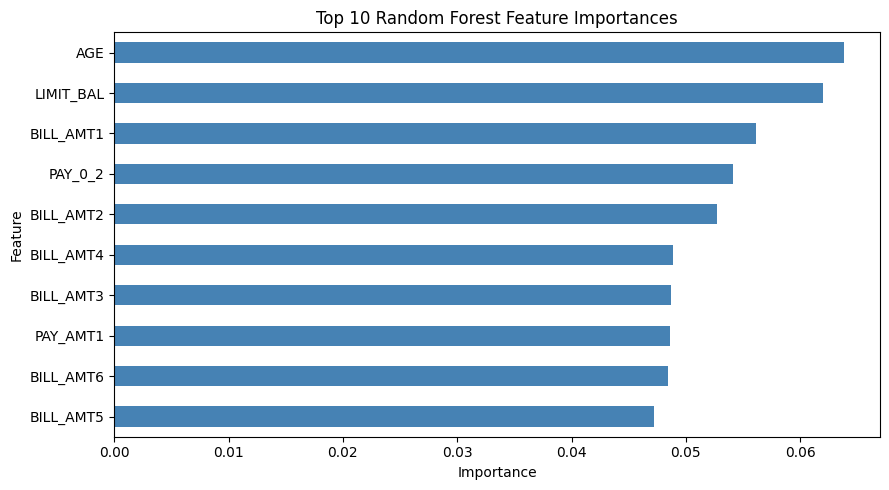

In [91]:
# Analyze feature importance
feature_names = (numerical_columns + encoder.get_feature_names_out(categorical_columns).tolist())
print("Processed features:", X_train_processed.shape[1])
print("Model features:", model.n_features_in_)
print("Feature names:", len(feature_names))
importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 10 features:")
print(importance.head(10).round(4))
# Title, label & display
importance.head(10).sort_values().plot(kind="barh", figsize=(9, 5), color="steelblue")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 4. Explainability and Fairness Analysis

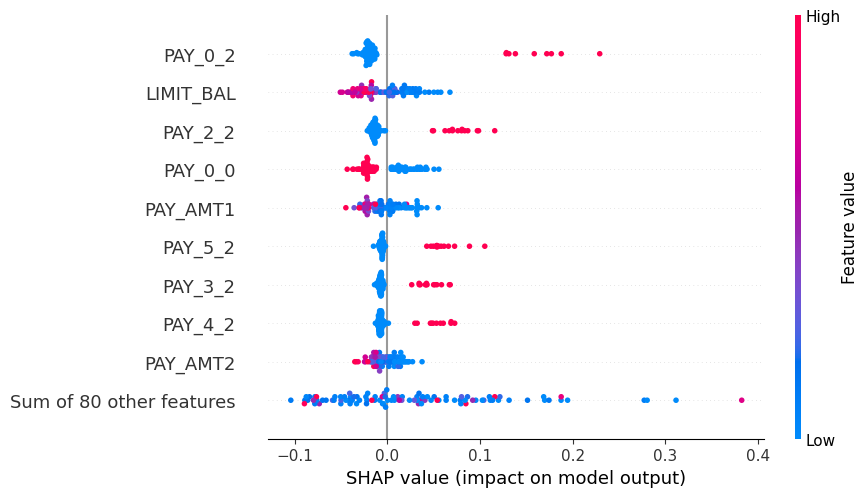

In [94]:
# Explain predictions with SHAP
sample = X_test_processed[:100]
explainer = shap.TreeExplainer(model)
shap_values = explainer(sample)
# Explain class 1: Default
default_shap = shap_values[:, :, 1]
default_shap.feature_names = feature_names
shap.plots.beeswarm(default_shap, max_display=10)

Predicted default probability: 0.11


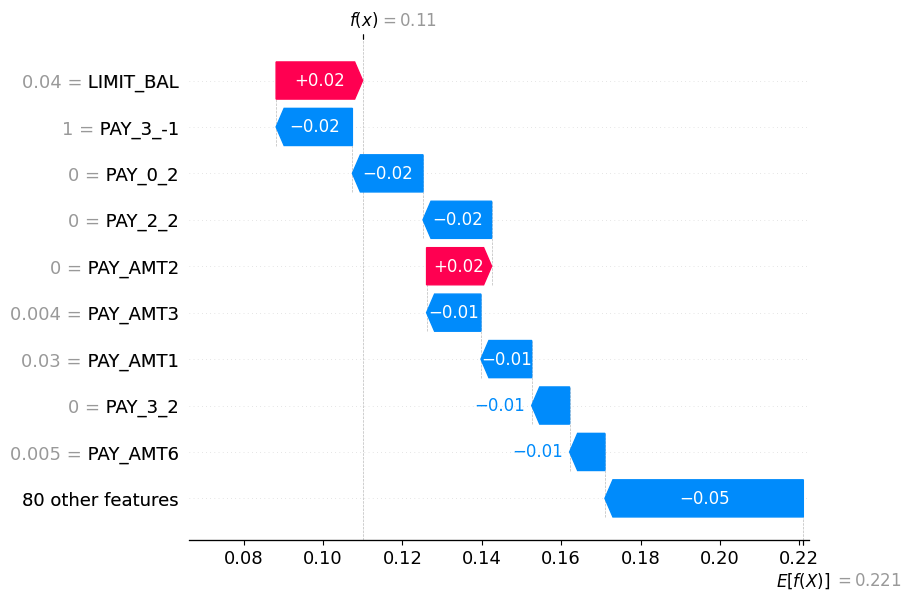

In [95]:
# Explain one individual prediction
print("Predicted default probability:", round(model.predict_proba(sample[:1])[0, 1], 4))
shap.plots.waterfall(default_shap[0], max_display=10)

In [96]:
# Compare performance across demographic groups
from sklearn.metrics import (accuracy_score, precision_score, recall_score, confusion_matrix)
results = []
for code, group in [(1, "Male"), (2, "Female")]:
    mask = (X_test["SEX"] == code).to_numpy()
    actual = y_test.to_numpy()[mask]
    predicted = y_pred[mask]
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
    results.append({
        "Group": group,
        "Count": len(actual),
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted, zero_division=0),
        "Recall": recall_score(actual, predicted, zero_division=0),
        "False positive rate": fp / (fp + tn) if fp + tn else np.nan
    })
fairness_results = pd.DataFrame(results).set_index("Group")
display(fairness_results.round(4))

,Count,Accuracy,Precision,Recall,False positive rate
Group,,,,,
Male,2402,0.8014,0.6321,0.3583,0.0636
Female,3598,0.8196,0.6383,0.3525,0.0540


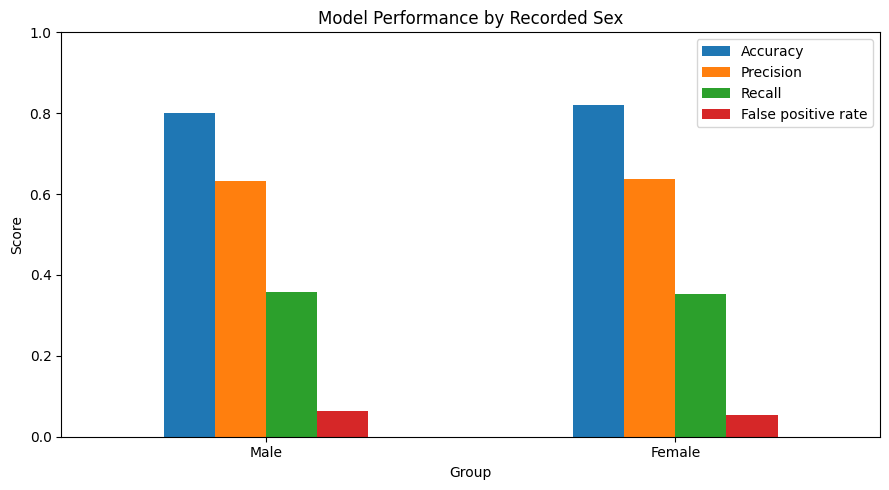

In [97]:
# Visualize the comparison
fairness_results.drop(columns="Count").plot(kind="bar", figsize=(9, 5), rot=0)
# Title & label
plt.title("Model Performance by Recorded Sex")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Ethical Considerations

#### Discussion
Fairness was assessed by comparing accuracy, precision, recall, and false positive rates across male and female groups. Privacy risks were reduced by using a public dataset and excluding client IDs from the model. SHAP explanations improved transparency by showing how individual features influenced predictions. However, these steps do not guarantee complete fairness or privacy.

#### Suggestion
Improvements include investigating performance gaps between groups and adjusting training sample weights where appropriate. The model should also be tested on more recent and representative data. Client information should be securely stored, and human review should support lending decisions to reduce the consequences of incorrect or biased predictions.

In [99]:
!find "/content/drive/MyDrive/Colab Notebooks" -iname "Assignment_15.ipynb"

find: ‘/content/drive/MyDrive/Colab Notebooks’: No such file or directory


In [100]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [101]:
!find "/content/drive/MyDrive/Colab Notebooks" -iname "Assignment_15.ipynb"

/content/drive/MyDrive/Colab Notebooks/Assignment_15.ipynb


In [102]:
!git clone https://github.com/StephaneTF/colab-git-assignment2-ST.git /content/colab-git-assignment2-ST

Cloning into '/content/colab-git-assignment2-ST'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 63 (delta 24), reused 26 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 2.79 MiB | 9.41 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [103]:
!ls -la /content/colab-git-assignment2-ST

total 3304
drwxr-xr-x 6 root root    4096 Sep 19 08:28  .
drwxr-xr-x 1 root root    4096 Sep 19 08:28  ..
-rw-r--r-- 1 root root    5415 Sep 19 08:28  assignment2.ipynb
drwxr-xr-x 2 root root    4096 Sep 19 08:28  Assignment_8
drwxr-xr-x 2 root root    4096 Sep 19 08:28  Assignment_9
drwxr-xr-x 8 root root    4096 Sep 19 08:28  .git
drwxr-xr-x 2 root root    4096 Sep 19 08:28  Lesson_10_assignment
-rw-r--r-- 1 root root   12704 Sep 19 08:28  Lesson_3_assignment.ipynb
-rw-r--r-- 1 root root   80271 Sep 19 08:28 'Lesson 4 assignment.ipynb'
-rw-r--r-- 1 root root  549515 Sep 19 08:28  Lesson_5_Assignment.ipynb
-rw-r--r-- 1 root root 2321005 Sep 19 08:28  Lesson_6_ml_basic_assignment.ipynb
-rw-r--r-- 1 root root  376413 Sep 19 08:28  Lesson_7_assignment.ipynb
